# Cadeias de Markov - Modelando a Incerteza no Mundo Real

### O Que É Uma Cadeia de Markov?

Uma **Cadeia de Markov** é um modelo matemático para sistemas que evoluem probabilisticamente ao longo do tempo.

**Definição Formal:**
Sistema estocástico onde a probabilidade de transição para o próximo estado **depende APENAS do estado atual**, não do histórico.

$$P(S_{t+1} | S_t, S_{t-1}, ..., S_0) = P(S_{t+1} | S_t)$$

Isso é chamado de **Propriedade de Markov** (ausência de memória)

### Exemplos do Mundo Real

| Exemplo | Estados | Transições |
|---------|---------|-----------|
| **Clima** | Ensolarado, Nublado, Chuvoso | Amanhã depende de hoje |
| **Redes Sociais** | Online, Offline | Usuário muda status |
| **Preço de Ação** | Alto, Médio, Baixo | Probabilidades de mudança |
| **Videogame** | Estados do jogo | Transições de gameplay |
| **Robot** | Posições | Movimento probabilístico |

### Por Que É Importante em RL?

-  Modela ambientes incertos realistically
-  Base teórica para MDPs (Markov Decision Processes)
-  Permite análise matemática (distribuição estacionária)
-  Predição e planejamento baseado em probabilidades

## Importações e Configuração

In [8]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

np.random.seed(42)  # Reprodutibilidade

In [9]:
# EXEMPLO 1: Sistema de Clima (Realista e Intuitivo)

print("EXEMPLO 1: PREVISÃO DE CLIMA COM CADEIA DE MARKOV")

# Estados do clima
climate_states = ['☀️ Ensolarado', '☁️ Nublado', '🌧️ Chuvoso']
state_abbrev = ['Sunny', 'Cloudy', 'Rainy']

# Matriz de Transição (Markov)
# Linha = Estado atual, Coluna = Próximo estado
# Baseado em padrões realistas de clima
P_climate = np.array([
    [0.80, 0.15, 0.05],  # De Ensolarado para: Ensolarado, Nublado, Chuvoso
    [0.40, 0.40, 0.20],  # De Nublado para: Ensolarado, Nublado, Chuvoso
    [0.10, 0.40, 0.50]   # De Chuvoso para: Ensolarado, Nublado, Chuvoso
])

print(f"Matriz de Transição (P):")
print(f"\nDe → Para      {state_abbrev[0]:>8}  {state_abbrev[1]:>8}  {state_abbrev[2]:>8}")
print("-" * 50)
for i, state in enumerate(climate_states):
    print(f"{state:15} {P_climate[i,0]:8.2f}  {P_climate[i,1]:8.2f}  {P_climate[i,2]:8.2f}")

print("\n Interpretação:")
print(f"  • Se está ☀️ Ensolarado, há 80% chance de continuar ensolarado amanhã")
print(f"  • Se está 🌧️ Chuvoso, há 50% chance de continuar chuvoso amanhã")
print(f"  • Padrão realista: sistemas tendem a persistir no estado atual")

# Criar grafo de Markov para clima
G_climate = nx.DiGraph()
G_climate.add_nodes_from(state_abbrev)

for i, from_state in enumerate(state_abbrev):
    for j, to_state in enumerate(state_abbrev):
        if P_climate[i,j] > 0:
            G_climate.add_edge(from_state, to_state, weight=P_climate[i,j])



EXEMPLO 1: PREVISÃO DE CLIMA COM CADEIA DE MARKOV
Matriz de Transição (P):

De → Para         Sunny    Cloudy     Rainy
--------------------------------------------------
☀️ Ensolarado       0.80      0.15      0.05
☁️ Nublado          0.40      0.40      0.20
🌧️ Chuvoso          0.10      0.40      0.50

 Interpretação:
  • Se está ☀️ Ensolarado, há 80% chance de continuar ensolarado amanhã
  • Se está 🌧️ Chuvoso, há 50% chance de continuar chuvoso amanhã
  • Padrão realista: sistemas tendem a persistir no estado atual


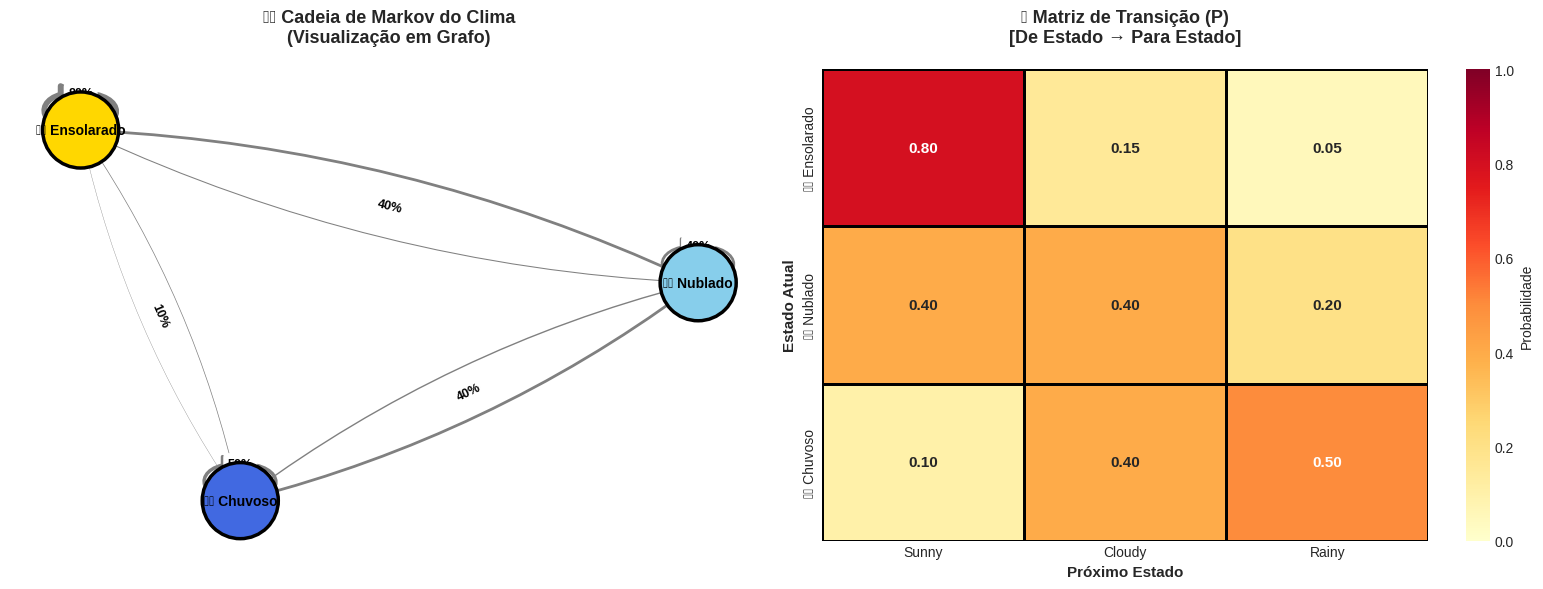

In [10]:
# VISUALIZAÇÃO 1: Grafo de Transição
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Gráfico 1: Grafo com Layout Circular ---
ax1 = axes[0]
pos = nx.spring_layout(G_climate, k=2, iterations=50, seed=42)

colors_climate = ['#FFD700', '#87CEEB', '#4169E1']  # Dourado, Azul claro, Azul escuro
nx.draw_networkx_nodes(G_climate, pos, node_size=3000, node_color=colors_climate,
                       ax=ax1, edgecolors='black', linewidths=2.5)

# Desenhar labels dos estados
node_labels = {abbrev: climate_states[i] for i, abbrev in enumerate(state_abbrev)}
nx.draw_networkx_labels(G_climate, pos, labels=node_labels, font_size=10,
                       font_weight='bold', ax=ax1)

# Desenhar arestas com espessuras proporcionais às probabilidades
edges = G_climate.edges()
weights = [G_climate[u][v]['weight'] for u, v in edges]

nx.draw_networkx_edges(G_climate, pos, width=[w*5 for w in weights],
                      edge_color='gray', arrowsize=25, arrowstyle='-|>',
                      arrows=True, ax=ax1, connectionstyle='arc3,rad=0.1')

# Labels das arestas (probabilidades)
edge_labels = {(u, v): f"{G_climate[u][v]['weight']:.0%}" for u, v in G_climate.edges()}
nx.draw_networkx_edge_labels(G_climate, pos, edge_labels=edge_labels, font_size=9,
                            font_weight='bold', ax=ax1)

ax1.set_title('🌦️ Cadeia de Markov do Clima\n(Visualização em Grafo)',
             fontsize=13, fontweight='bold', pad=20)
ax1.axis('off')

# --- Gráfico 2: Matriz de Transição em Heatmap ---
ax2 = axes[1]
sns.heatmap(P_climate, annot=True, fmt='.2f', cmap='YlOrRd', cbar_kws={'label': 'Probabilidade'},
           xticklabels=state_abbrev, yticklabels=climate_states, ax=ax2,
           linewidths=2, linecolor='black', cbar=True, vmin=0, vmax=1,
           annot_kws={'size': 11, 'weight': 'bold'})

ax2.set_title('📊 Matriz de Transição (P)\n[De Estado → Para Estado]',
             fontsize=13, fontweight='bold', pad=20)
ax2.set_xlabel('Próximo Estado', fontweight='bold', fontsize=11)
ax2.set_ylabel('Estado Atual', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

## Simulação: Trajetórias Aleatórias no Clima

In [11]:
print("\n" + "="*70)

def simulate_markov_chain(P, initial_state=0, num_steps=5):
    """
    Simula transições em uma Cadeia de Markov.

    Parâmetros:
    - P: matriz de transição
    - initial_state: índice do estado inicial
    - num_steps: número de passos a simular

    Retorno:
    - trajectory: sequência de estados visitados
    """
    trajectory = [initial_state]
    current_state = initial_state

    for _ in range(num_steps):
        # Próximo estado baseado na probabilidade
        next_state = np.random.choice(len(P), p=P[current_state])
        trajectory.append(next_state)
        current_state = next_state

    return trajectory

# Simular 3 cenários diferentes
num_simulations = 3
num_steps = 7

print(f"Simulando {num_simulations} sequências de {num_steps} dias:\n")

trajectories = []
for sim_idx in range(num_simulations):
    initial_state = np.random.randint(0, 3)
    trajectory = simulate_markov_chain(P_climate, initial_state, num_steps)
    trajectories.append(trajectory)

    print(f"Simulação {sim_idx + 1}:")
    print("  ", end="")
    for state in trajectory:
        print(climate_states[state], end=" → ")
    print("...\n")

# Calcular frequências
print("Estatísticas das Simulações:")
print("-" * 70)
all_states = [state for traj in trajectories for state in traj]
for i, state in enumerate(climate_states):
    count = all_states.count(i)
    pct = count / len(all_states) * 100
    print(f"{state:15} {count:3d} ocorrências ({pct:.1f}%)")


Simulando 3 sequências de 7 dias:

Simulação 1:
  🌧️ Chuvoso → 🌧️ Chuvoso → ☁️ Nublado → ☁️ Nublado → ☁️ Nublado → ☁️ Nublado → ☀️ Ensolarado → ☀️ Ensolarado → ...

Simulação 2:
  ☀️ Ensolarado → ☀️ Ensolarado → ☀️ Ensolarado → ☀️ Ensolarado → 🌧️ Chuvoso → 🌧️ Chuvoso → ☁️ Nublado → ☀️ Ensolarado → ...

Simulação 3:
  ☀️ Ensolarado → ☀️ Ensolarado → ☀️ Ensolarado → ☀️ Ensolarado → ☀️ Ensolarado → ☀️ Ensolarado → ☀️ Ensolarado → ☀️ Ensolarado → ...

Estatísticas das Simulações:
----------------------------------------------------------------------
☀️ Ensolarado    15 ocorrências (62.5%)
☁️ Nublado        5 ocorrências (20.8%)
🌧️ Chuvoso        4 ocorrências (16.7%)


## Visualização: Trajetórias no Tempo

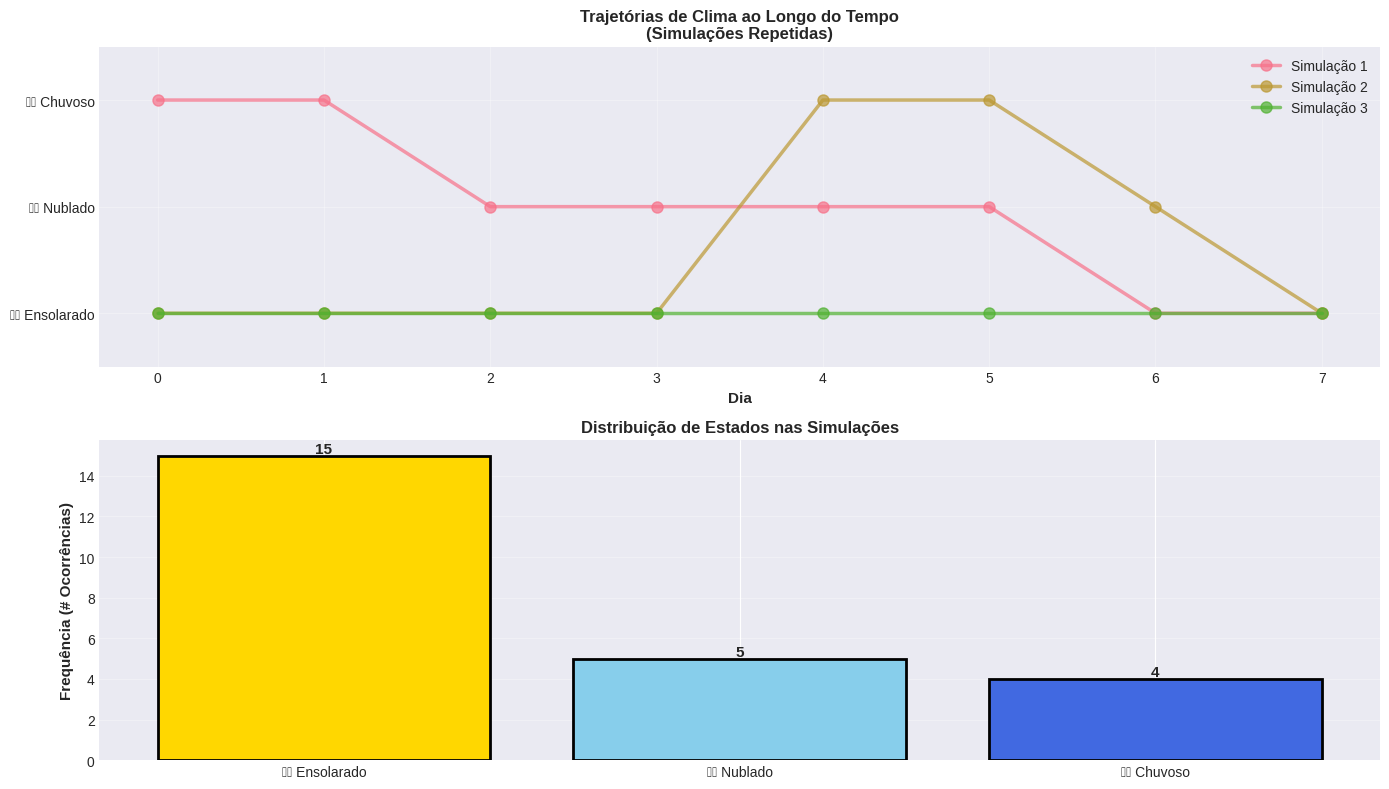

In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

colors = ['#FFD700', '#87CEEB', '#4169E1']
color_names = ['Ensolarado', 'Nublado', 'Chuvoso']

# --- Gráfico 1: Trajetórias Individuais ---
for sim_idx, trajectory in enumerate(trajectories):
    state_indices = trajectory
    ax1.plot(range(len(state_indices)), state_indices, 'o-', linewidth=2.5,
            markersize=8, label=f'Simulação {sim_idx + 1}', alpha=0.7)

ax1.set_yticks([0, 1, 2])
ax1.set_yticklabels(climate_states, fontsize=10)
ax1.set_xlabel('Dia', fontweight='bold', fontsize=11)
ax1.set_title('Trajetórias de Clima ao Longo do Tempo\n(Simulações Repetidas)',
             fontweight='bold', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right', fontsize=10)
ax1.set_ylim(-0.5, 2.5)

# --- Gráfico 2: Distribuição de Frequências ---
all_states = [state for traj in trajectories for state in traj]
state_counts = [all_states.count(i) for i in range(3)]

bars = ax2.bar(climate_states, state_counts, color=colors, edgecolor='black', linewidth=2)
ax2.set_ylabel('Frequência (# Ocorrências)', fontweight='bold', fontsize=11)
ax2.set_title('Distribuição de Estados nas Simulações', fontweight='bold', fontsize=12)
ax2.grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for bar, count in zip(bars, state_counts):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()